In [1]:
from langchain.chat_models import init_chat_model


In [2]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b
    Args:
      a: first int
      b: Second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b
    Args:
      a: first int
      b: Second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b
    Args:
      a: first int
      b: Second int
    """
    return a / b

In [3]:
tools = [add, multiply, divide]
llm =  init_chat_model("gemini-2.0-flash-001", model_provider="google_vertexai")
llm_with_tools = llm.bind_tools(tools)

In [4]:
from utils import draw_graph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage

In [5]:
# System Message
system_message = SystemMessage(content="You are an helpful assistant who can perform arthimetic operations")

# Node
def assistant(state: MessagesState) -> MessagesState:
    return {"messages": [llm_with_tools.invoke([system_message] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Define edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)

builder.add_edge("tools", "assistant")

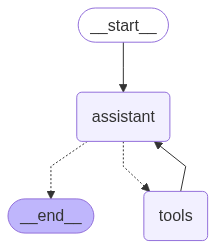

In [6]:
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)
draw_graph(graph)

In [7]:
# input
initial_input = {"messages": HumanMessage(content="multiply 3 and 5")}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph
for event in graph.stream(
    input=initial_input,
    config=thread,
    stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

multiply 3 and 5
================================== Ai Message ==================================
Tool Calls:
  multiply (e93ae667-998a-4df7-924e-9d8b33943501)
 Call ID: e93ae667-998a-4df7-924e-9d8b33943501
  Args:
    a: 3.0
    b: 5.0
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The result of multiplying 3 and 5 is 15.


##Browsing History

In [8]:
graph.get_state(config=thread)


StateSnapshot(values={'messages': [HumanMessage(content='multiply 3 and 5', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 3.0, "b": 5.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 99, 'candidates_token_count': 5, 'total_token_count': 104, 'prompt_tokens_details': [{'modality': 1, 'token_count': 99}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 5}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash-001'}, id='run--bbfd215b-d850-4e28-b3a1-66e5b5881b98-0', tool_calls=[{'name': 'multiply', 'args': {'a': 3.0, 'b': 5.0}, 'id': 'e93ae667-998a-4df7-924e-9d8b33943501', 'type': 'tool_call'}], usage_metadata={'input_tokens': 99, 'output_tokens': 5, 'total_tokens': 104}), ToolMessage(c

In [9]:
all_states = [ state for state in graph.get_state_history(thread)]


In [10]:
len(all_states)


5

In [11]:
all_states[-2]


StateSnapshot(values={'messages': [HumanMessage(content='multiply 3 and 5', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f049afe-69f8-60d7-8000-efecd4ef55a7'}}, metadata={'source': 'loop', 'writes': None, 'step': 0, 'parents': {}, 'thread_id': '1'}, created_at='2025-06-15T06:13:48.580271+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f049afe-68c2-693b-bfff-7fad85fa7796'}}, tasks=(PregelTask(id='ed653b2e-a1f0-decd-a506-3bcc2dea9b8b', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 3.0, "b": 5.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 99, 'candidates_token_count

In [12]:
to_replay = all_states[-2]


In [13]:
to_replay

StateSnapshot(values={'messages': [HumanMessage(content='multiply 3 and 5', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f049afe-69f8-60d7-8000-efecd4ef55a7'}}, metadata={'source': 'loop', 'writes': None, 'step': 0, 'parents': {}, 'thread_id': '1'}, created_at='2025-06-15T06:13:48.580271+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f049afe-68c2-693b-bfff-7fad85fa7796'}}, tasks=(PregelTask(id='ed653b2e-a1f0-decd-a506-3bcc2dea9b8b', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result={'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'multiply', 'arguments': '{"a": 3.0, "b": 5.0}'}}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 99, 'candidates_token_count

In [14]:
to_replay.values


{'messages': [HumanMessage(content='multiply 3 and 5', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33')]}

In [15]:
to_replay.next


('assistant',)

In [16]:
to_replay.config


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f049afe-69f8-60d7-8000-efecd4ef55a7'}}

In [ ]:
for event in graph.stream(input=None, config=to_replay.config, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

multiply 3 and 5
================================== Ai Message ==================================
Tool Calls:
  multiply (c428400f-26fc-4db5-830c-d9cc50a3e8e4)
 Call ID: c428400f-26fc-4db5-830c-d9cc50a3e8e4
  Args:
    a: 3.0
    b: 5.0
================================= Tool Message =================================
Name: multiply

15
================================== Ai Message ==================================

The result of multiplying 3 and 5 is 15.


Forking

In [18]:
to_fork = all_states[-2]
to_fork.values["messages"]

[HumanMessage(content='multiply 3 and 5', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33')]

In [19]:
to_fork.config


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f049afe-69f8-60d7-8000-efecd4ef55a7'}}

In [20]:
# to modify state
fork_config = graph.update_state(
    to_fork.config, # old config
    {"messages": [HumanMessage(content='Add 5 and 3', id = to_fork.values["messages"][0].id)]},

    )

In [21]:
fork_config


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f049b05-68a3-63d2-8001-e3da05d8e35a'}}

In [22]:
all_states = [ state for state in graph.get_state_history(thread)]
all_states[0].values["messages"]

[HumanMessage(content='Add 5 and 3', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33')]

In [23]:
graph.get_state(thread)


StateSnapshot(values={'messages': [HumanMessage(content='Add 5 and 3', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33')]}, next=('assistant',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f049b05-68a3-63d2-8001-e3da05d8e35a'}}, metadata={'source': 'update', 'writes': {'__start__': {'messages': [HumanMessage(content='Add 5 and 3', additional_kwargs={}, response_metadata={}, id='daa9cc35-0df8-4ddd-9754-31cbd7c77e33')]}}, 'step': 1, 'parents': {}, 'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f049afe-69f8-60d7-8000-efecd4ef55a7'}, created_at='2025-06-15T06:16:56.345493+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f049afe-69f8-60d7-8000-efecd4ef55a7'}}, tasks=(PregelTask(id='230cadcf-088f-331c-dc87-366f676549f0', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [24]:
for event in graph.stream(None, fork_config, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Add 5 and 3
================================== Ai Message ==================================
Tool Calls:
  add (56cab17f-34d7-45cd-95d8-49b88c08180b)
 Call ID: 56cab17f-34d7-45cd-95d8-49b88c08180b
  Args:
    a: 5.0
    b: 3.0
================================= Tool Message =================================
Name: add

8
================================== Ai Message ==================================

The sum of 5 and 3 is 8.
